In [1]:
# load the necessary packages
library("tidyverse")
library("lme4")
library("emmeans")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



In [2]:
# load the data
data <- read.csv('df_ampw_vs_loss.csv')

In [3]:
data$upper_bound <- as.factor(data$upper_bound)

In [4]:
model = lmer(loss ~ 1 + ampw*v1_unit+upper_bound + (1+ampw|dlgn_unit), data = data)

In [5]:
summary(model)

Linear mixed model fit by REML ['lmerMod']
Formula: loss ~ 1 + ampw * v1_unit + upper_bound + (1 + ampw | dlgn_unit)
   Data: data

REML criterion at convergence: -102374.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.9692 -0.5201 -0.1507  0.3434 11.8092 

Random effects:
 Groups    Name        Variance  Std.Dev. Corr 
 dlgn_unit (Intercept) 6.661e-05 0.008162      
           ampw        3.414e-02 0.184769 -0.35
 Residual              1.970e-04 0.014037      
Number of obs: 18000, groups:  dlgn_unit, 6

Fixed effects:
                  Estimate Std. Error t value
(Intercept)      0.0667366  0.0105628   6.318
ampw             0.6180133  0.2392309   2.583
v1_unit          0.0036108  0.0066819   0.540
upper_bound0.16  0.0059354  0.0002732  21.728
upper_bound0.24  0.0129754  0.0003226  40.220
ampw:v1_unit    -0.2408683  0.1515734  -1.589

Correlation of Fixed Effects:
            (Intr) ampw   v1_unt u_0.16 u_0.24
ampw        -0.353                            
v1_unit  

In [6]:
## Test the significance of each effect

effect_significance = data.frame(joint_tests(model))
effect_significance

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



,model.term,df1,df2,F.ratio,Chisq,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ampw,1,Inf,11.439,11.439,0.0007192533
3,v1_unit,1,Inf,1.126,1.126,0.2886680278
4,upper_bound,2,Inf,811.029,1622.058,0.0000000000
2,ampw:v1_unit,1,Inf,2.525,2.525,0.1120332012


In [7]:
## get the predicted intercept for each group

intercept_pred = emmeans(
    model, 
    pairwise ~ v1_unit*upper_bound|ampw,
    at = list(ampw = c(0.0)) 
)$emmeans %>% data.frame()
intercept_pred

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



,v1_unit,upper_bound,ampw,emmean,SE,df,asymp.LCL,asymp.UCL
,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0.08,0,0.07034746,0.004723558,Inf,0.06108946,0.07960546
2,2,0.08,0,0.07395828,0.004727273,Inf,0.06469299,0.08322356
3,1,0.16,0,0.07628286,0.004727420,Inf,0.06701729,0.08554843
4,2,0.16,0,0.07989368,0.004732169,Inf,0.07061880,0.08916856
5,1,0.24,0,0.08332290,0.004733721,Inf,0.07404498,0.09260082
6,2,0.24,0,0.08693372,0.004739505,Inf,0.07764446,0.09622298


In [8]:
## Get intercept contrasts
intercept_contrasts = emmeans(
    model, 
    pairwise ~ upper_bound|ampw,
    at = list(ampw = c(0.0)) 
)$emmeans  %>% pairs()  %>% data.frame()

intercept_contrasts

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



,contrast,ampw,estimate,SE,df,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,upper_bound0.08 - upper_bound0.16,0,-0.005935401,0.0002731671,Inf,-21.72809,0
2,upper_bound0.08 - upper_bound0.24,0,-0.012975441,0.0003226124,Inf,-40.21991,0
3,upper_bound0.16 - upper_bound0.24,0,-0.007040039,0.0002756737,Inf,-25.53758,0


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



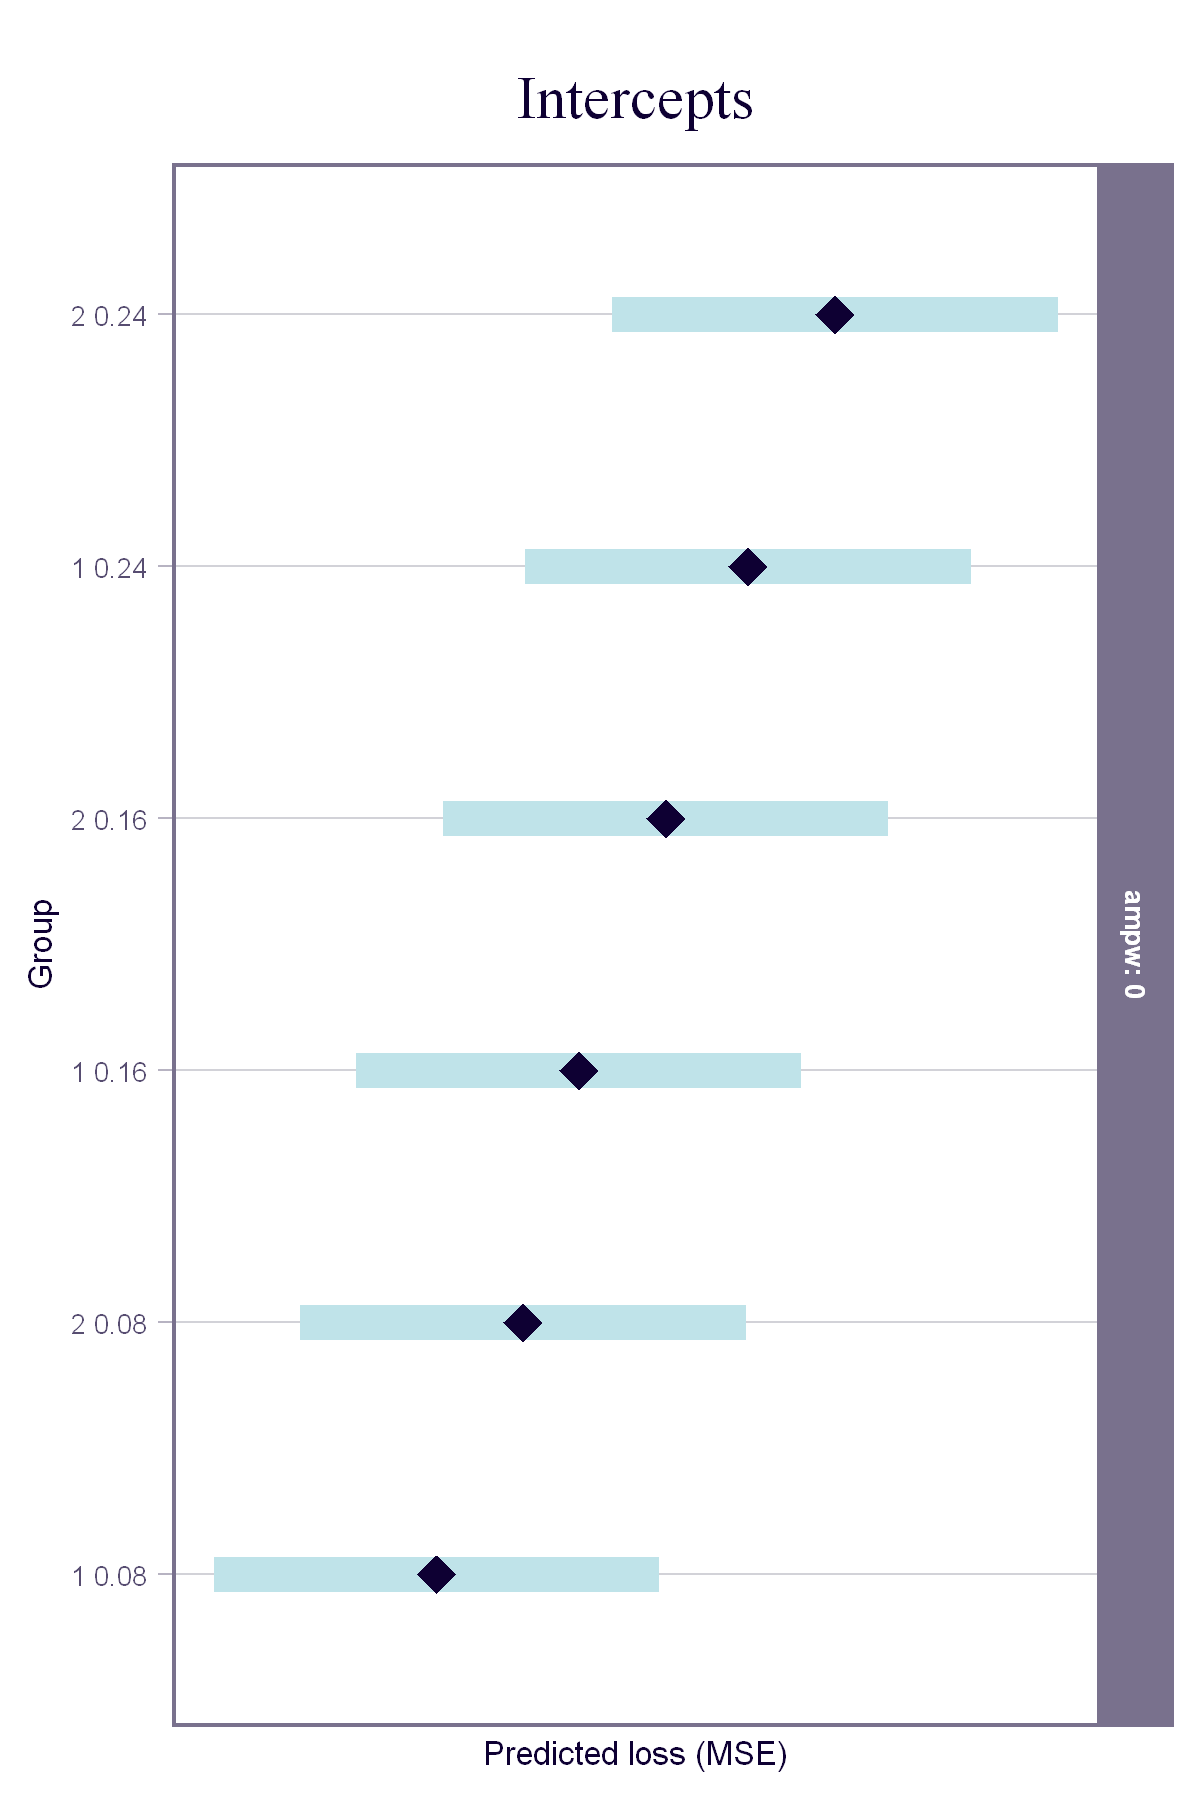

In [9]:
# adjust figure attributes:
options(
    repr.plot.width = 4, 
    repr.plot.height = 6, 
    repr.plot.res = 300
)

emmeans(
    model, 
    pairwise ~ v1_unit+upper_bound|ampw,
    at = list(ampw = c(0.0)) 
)$emmeans %>% plot() +
    labs(
        x = 'Predicted loss (MSE)',
        y = 'Group',
        title = 'Intercepts'
    ) + 
    geom_point(size=0.05) +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(text = element_text(size = 8)) +
    scale_x_continuous(labels = seq(0,250,10), breaks = seq(0,250,10))

In [10]:
## get the predicted slope for each group

slope_pred = emtrends(
    model, 
    var = 'ampw', 
    specs = c('v1_unit', 'upper_bound') 
) %>% data.frame()
slope_pred

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



,v1_unit,upper_bound,ampw.trend,SE,df,asymp.LCL,asymp.UCL
,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0.08,0.3771450,0.1069142,Inf,0.1675969,0.5866930
2,2,0.08,0.1362767,0.1076050,Inf,-0.0746252,0.3471785
3,1,0.16,0.3771450,0.1069142,Inf,0.1675969,0.5866930
4,2,0.16,0.1362767,0.1076050,Inf,-0.0746252,0.3471785
5,1,0.24,0.3771450,0.1069142,Inf,0.1675969,0.5866930
6,2,0.24,0.1362767,0.1076050,Inf,-0.0746252,0.3471785


In [11]:
## Get slope contrasts

slope_contrasts = emtrends(
    model, 
    var = 'ampw',
    specs = c('v1_unit', 'upper_bound') 
)  %>% pairs()  %>% data.frame()
slope_contrasts

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



,contrast,estimate,SE,df,z.ratio,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,v1_unit1 upper_bound0.08 - v1_unit2 upper_bound0.08,0.2408683,0.1515734,Inf,1.58912,0.4786553
2,v1_unit1 upper_bound0.08 - v1_unit1 upper_bound0.16,0.0000000,0.0000000,Inf,NaN,NaN
3,v1_unit1 upper_bound0.08 - v1_unit2 upper_bound0.16,0.2408683,0.1515734,Inf,1.58912,0.4786553
4,v1_unit1 upper_bound0.08 - v1_unit1 upper_bound0.24,0.0000000,0.0000000,Inf,NaN,NaN
5,v1_unit1 upper_bound0.08 - v1_unit2 upper_bound0.24,0.2408683,0.1515734,Inf,1.58912,0.4786553
6,v1_unit2 upper_bound0.08 - v1_unit1 upper_bound0.16,-0.2408683,0.1515734,Inf,-1.58912,0.4786553
7,v1_unit2 upper_bound0.08 - v1_unit2 upper_bound0.16,0.0000000,0.0000000,Inf,NaN,NaN
8,v1_unit2 upper_bound0.08 - v1_unit1 upper_bound0.24,-0.2408683,0.1515734,Inf,-1.58912,0.4786553
9,v1_unit2 upper_bound0.08 - v1_unit2 upper_bound0.24,0.0000000,0.0000000,Inf,NaN,NaN


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



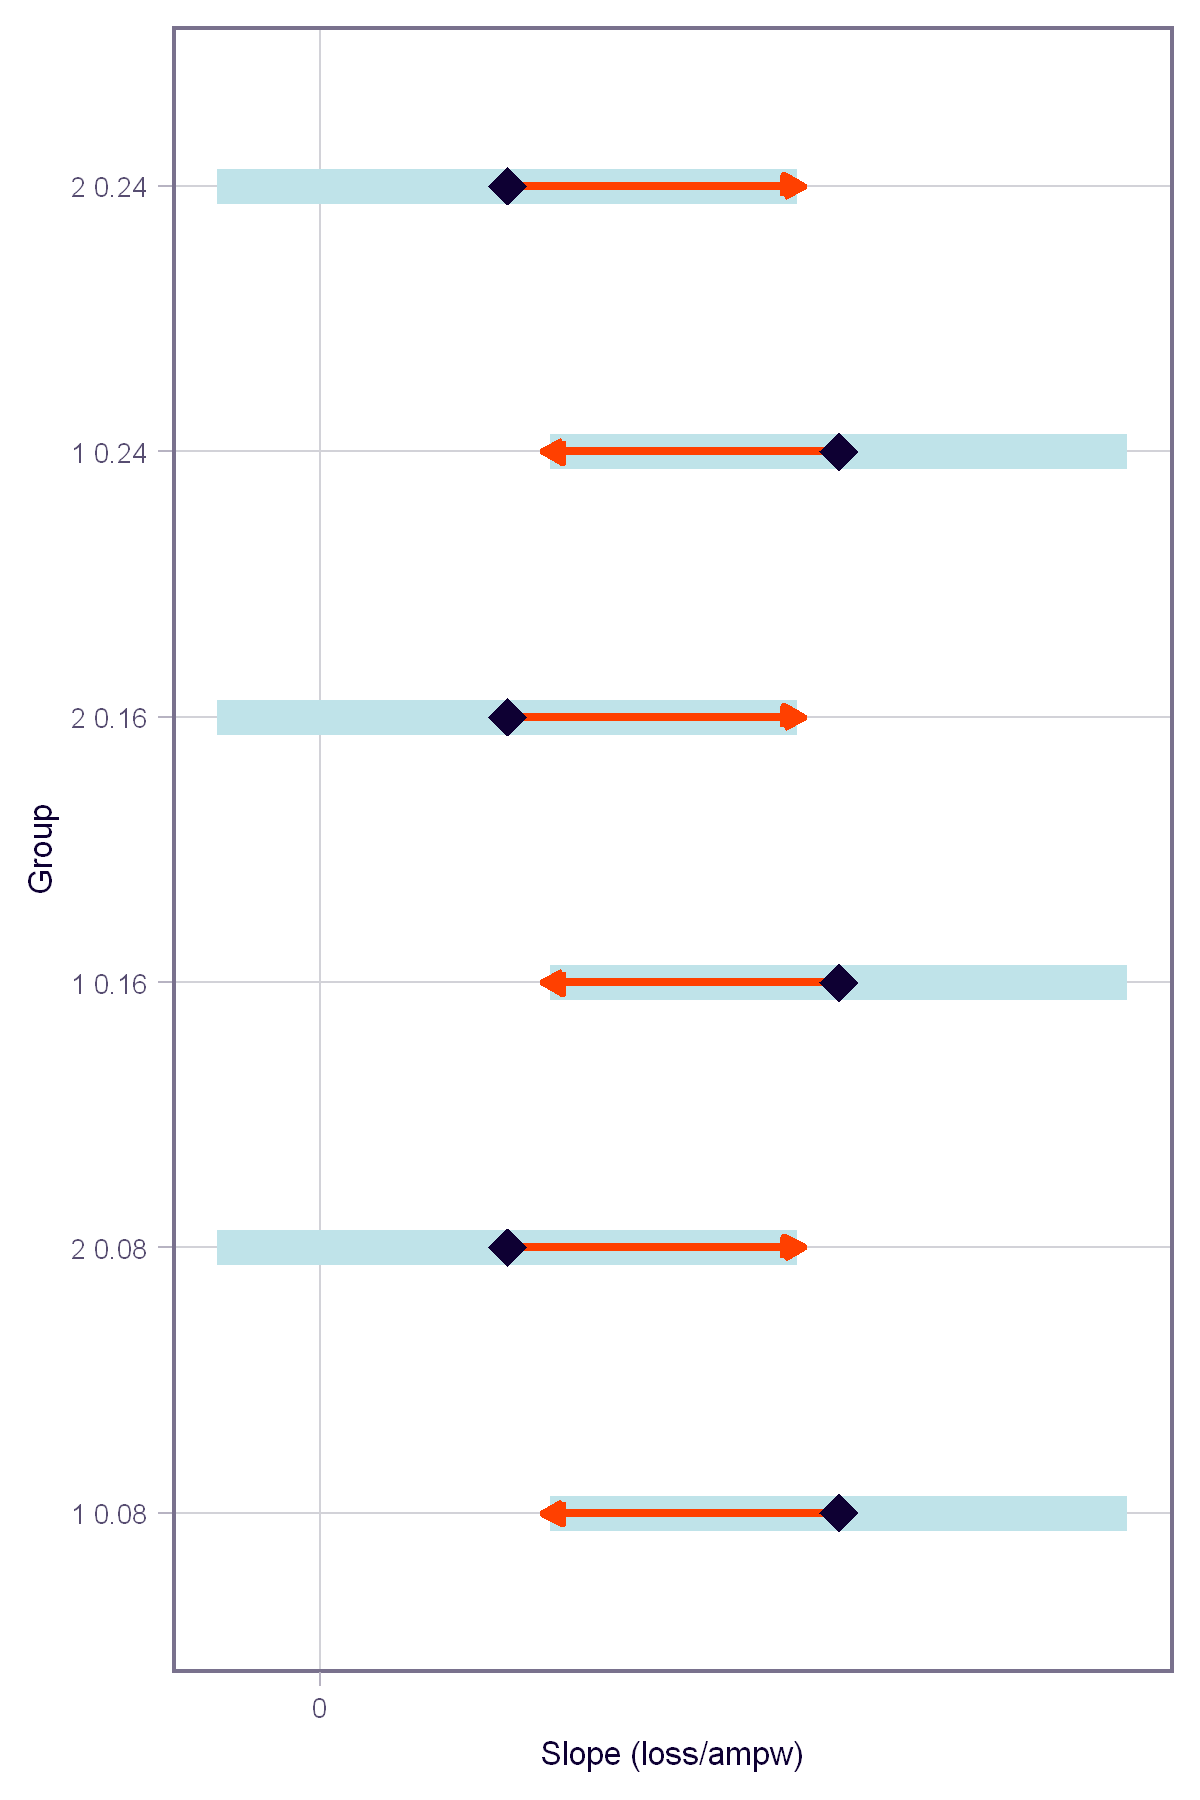

In [12]:
options(
    repr.plot.width = 4, 
    repr.plot.height = 6, 
    repr.plot.res = 300
)

emtrends(
    model, 
    var = 'ampw', 
    specs = c('v1_unit', 'upper_bound')
) %>% plot(comparisons = TRUE,) +     
    labs(
        x = 'Slope (loss/ampw)',
        y = 'Group',
    ) +
    geom_point(size=0.05)+
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(text = element_text(size = 8)) +
    scale_x_continuous(labels = seq(0,250,10), breaks = seq(0,250,10))

In [13]:
fixed_effects = as.data.frame(fixef(model))
fixed_effects

,fixef(model)
,<dbl>
(Intercept),0.066736641
ampw,0.618013289
v1_unit,0.003610818
upper_bound0.16,0.005935401
upper_bound0.24,0.012975441
ampw:v1_unit,-0.240868315


In [14]:
random_effects = as.data.frame(ranef(model, condvar = TRUE))  %>% pivot_wider(
    names_from = term,
    values_from = c(condval, condsd)
)
random_effects

Warning message in ranef.merMod(model, condvar = TRUE):
"additional arguments to ranef.merMod ignored: condvar"


grpvar,grp,condval_(Intercept),condval_ampw,condsd_(Intercept),condsd_ampw
<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
dlgn_unit,1_1,0.0103174636,0.08090092,0.0004960799,0.005612666
dlgn_unit,1_2,-0.0113004148,0.19230247,0.0005927961,0.015171213
dlgn_unit,1_3,0.0009829512,-0.27320339,0.0005577595,0.010304177
dlgn_unit,2_1,0.0041410838,-0.03561482,0.0005055241,0.004999294
dlgn_unit,2_2,-0.0035131098,0.10488053,0.0008325344,0.036592629
dlgn_unit,2_3,-0.0006279739,-0.06926571,0.0005140534,0.010911564


In [15]:
write.csv(fixed_effects, 'ampw_fixef.csv')
write.csv(random_effects, 'ampw_ranef.csv')
write.csv(intercept_pred, 'ampw_intercepts.csv')
write.csv(slope_pred, 'ampw_slopes.csv')